In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import scipy.io as io
import argparse

import src.models.models as models
import src.training.self_supervision as ssl
import src.utils.utils as utils
import src.utils.extractor as extractor

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

/home/ids/edabier/.local/lib/python3.10/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 28] No space left on device.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attrib

False


/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


162


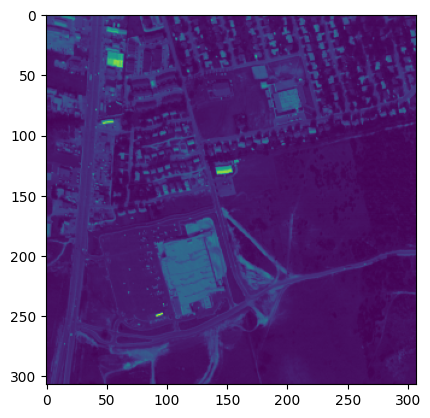

In [2]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"])
Y_flat = Y_flat.to(torch.float32)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]
print(B)

Y = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
H, W = Y.shape[-1], Y.shape[-1]
W = H

patch_size = 64
batch_size = 10

plt.imshow(Y.cpu()[10,:,:])

In [3]:
# mu_model = models.MU(N_iter=1000)
# e_hat, a_hat, y_hat, y_hats = mu_model(Y_flat, c)

# a_hat = utils.oneD_to_2d(a_hat)
# y_hat = utils.oneD_to_2d(y_hat)
# y_hats = [utils.oneD_to_2d(y_hats[i]) for i in range(len(y_hats))]
# mse = nn.MSELoss()
# loss = [mse(Y, y_hats[i]) for i in range(len(y_hats))]
# plt.plot(loss)
# mse, sad = utils.compute_metrics_and_plot(e_hat, E, a_hat, A)

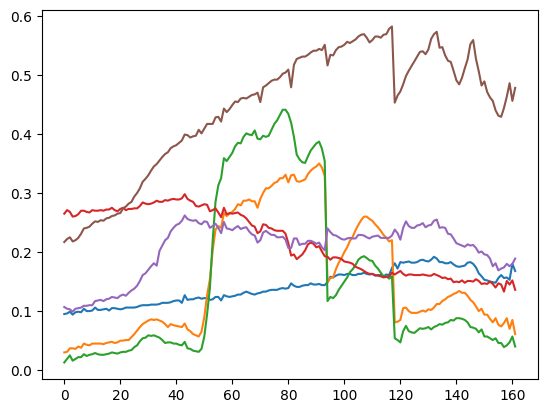

In [4]:
E = extractor.SiVM(Y_flat, c, E)
plt.plot(E[0, :,:].cpu())

In [5]:
# dataset_full = utils.HSI_dataset(dataset=dataset)
# dataset_patched = utils.HSI_dataset(dataset=dataset, patch_size=patch_size)
# full_loader = DataLoader(dataset_full)
# patched_loader = DataLoader(dataset_patched)

# full_loader, _, _ = utils.create_dataloader(dataset, "datasets/", dev, batch_size=batch_size)
full_loader = utils.get_dataloader(dataset, patch_size, batch_size)

## Models

In [6]:
# """
# MLP: Adam "poly" learning rate policy lr=0.1 * (1-iter/max_iter)**0.99, rate_dropout=0.9
# """
# mlpae = models.MLP_AE(B=B, c=c)
# print("MLP: ", sum(p.numel() for p in mlpae.parameters() if p.requires_grad)/1e6, "M")

# """
# CNN + linear decoder
# """
# cnnlinear = models.CNNAE_linear(B=B, c=c, patch_size=patch_size)
# print("CNN + linear decoder: ", sum(p.numel() for p in cnnlinear.parameters() if p.requires_grad)/1e6, "M")

"""
CNNAEU: epochs=320, lr=0.0003, batch=15
"""
Y_init, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]
cnnaeu = models.CNNAEU(B=B, c =c)
cnnaeu = models.init_decoder_weights(cnnaeu, Y_init, c, 11)
print("CNNAEU: ", sum(p.numel() for p in cnnaeu.parameters() if p.requires_grad)/1e6, "M")

"""
Deep Trans: patch_size=5, a*L_RE + b*L_SAD (a ≃ 1e5*b), epochs=200, lr=6-9e-3 -20% every 15epochs, 
weight decay rate 4e-5 (inside adamw)
"""
Y_trans = Y[:,:(Y.shape[1]//patch_size)*patch_size,:(Y.shape[1]//patch_size)*patch_size]
deep_trans = models.DeepTrans(B=B, c=c, patch_size=patch_size, im_size=Y_trans.shape[1], dim=200)
deep_trans = models.init_decoder_weights(deep_trans, Y_init, c)
print("Deep trans: ", sum(p.numel() for p in deep_trans.parameters() if p.requires_grad)/1e6, "M")

"""
UnDIP
"""
undip = models.UnDIP(B=B, c=c)
print("UnDIP: ", sum(p.numel() for p in undip.parameters() if p.requires_grad)/1e6, "M")

"""
NALMU
"""
nalmu = models.NALMU(T=25, B=B, c=c, N=N)
print("NALMU: ", sum(p.numel() for p in nalmu.parameters() if p.requires_grad)/1e6, "M")

"""
RALMU
"""
ralmu = models.RALMU(T=25, B=B, c=c, im_size=H)
print("RALMU: ", sum(p.numel() for p in ralmu.parameters() if p.requires_grad)/1e6, "M")

CNNAEU:  0.187992 M
Deep trans:  24.824366 M
UnDIP:  1.633442 M
NALMU:  0.0243 M
RALMU:  6.447025 M


/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/torch/nn/init.py:566: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


## Debuging results (permutation, Normalization of GT and prediction...)

Check the normalization of predictions for every model (DeepTrans)

Understand wandb not logging images

Understand MSE computation problem (compare NALMU A maps)

Compare HyperSig code to DOFA and SpectralEarth to know how to use them

Check the meaning of all norm layers in deep_trans

In [7]:
model = cnnaeu
model_name = model.__class__.__name__

if model_name == "RALMU" or model_name == "NALMU":
    model_name += str(model.T)
    lr = 0.00001
else:
    lr = 0.003

if model_name == "DeepTrans":
    Y_flat, A_flat = utils.crop_patch_image(Y_flat, patch_size, A_flat)

state_dict = torch.load(f"/home/ids/edabier/HSU/SS-HSU_benchmark/models/{model_name}_Basic_{dataset}_lr_{lr}.pt", map_location=dev)["model_state_dict"]
model.load_state_dict(state_dict, strict=False)

E_hat, A_hat, Y_hat = model(Y_flat)
A_hat = utils.oneD_to_2d(A_hat)[0]
Y_hat = utils.oneD_to_2d(Y_hat)[0]
A = utils.oneD_to_2d(A_flat)
if E_hat.dim() == 3:
    E_hat = E_hat.squeeze(0)

In [8]:
A_ordered = torch.stack([A_hat[1], A_hat[2], A_hat[3], A_hat[4], A_hat[0], A_hat[5]], dim=0)
E_ordered = torch.stack([E_hat[:,1], E_hat[:,2], E_hat[:,3], E_hat[:,4], E_hat[:,0], E_hat[:,5]], dim=1)

mse = nn.MSELoss(reduction="sum")
sad = utils.SADLoss()
loss_mse = mse(A, A_ordered)/(torch.norm(A)**2)
loss_sad = sad(E[0], E_ordered)
print("MSE:", round(loss_mse.item(), 3), "- SAD:", round(loss_sad.item(), 3))

MSE: 0.213 - SAD: 0.705


MSE: 0.306 - SAD: 0.64


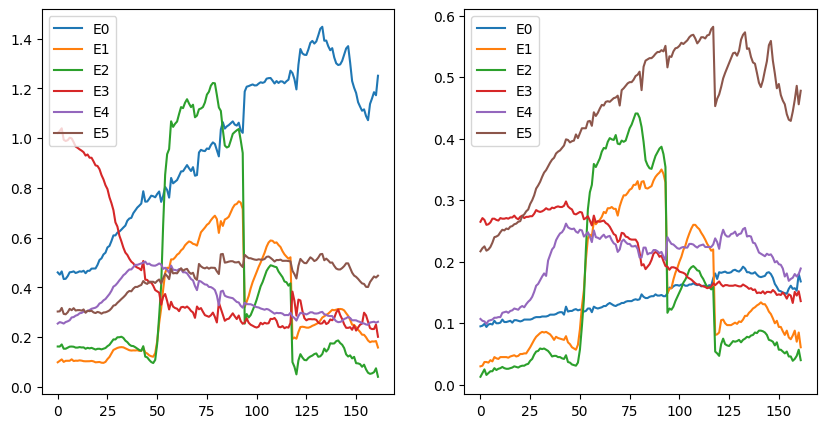

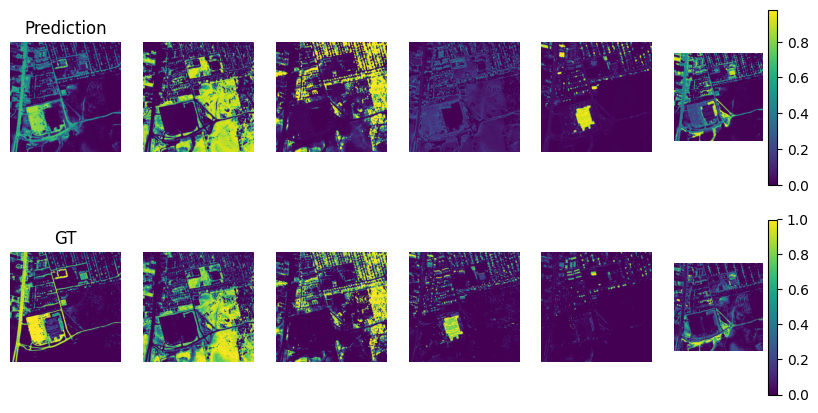

In [59]:
E_ordered, E_ordered_norm, A_ordered, indices = utils.order_endmembers(E, E_hat, A_hat)
A_ordered = A_ordered.squeeze(0)
E_ordered = E_ordered.squeeze(0)
# A_ordered, A_ordered_norm, E_ordered, indices = order_abundances(A, A_hat, E_hat)

# E_ordered = E_hat
# A_ordered = A_hat

mse = nn.MSELoss(reduction="sum")
sad = utils.SADLoss()
loss_mse = mse(A, A_ordered)/(torch.norm(A)**2)
loss_sad = sad(E[0], E_ordered)
print("MSE:", round(loss_mse.item(), 3), "- SAD:", round(loss_sad.item(), 3))

fig, axs = plt.subplots(1,2, figsize=(10,5))
for i in range(E_ordered.shape[1]):
    axs[0].plot(E_ordered[:, i], color=f'C{i}', label=f"E{i}")
    axs[1].plot(E[0, :, i], color=f'C{i}', label=f"E{i}")
axs[0].legend()
axs[1].legend()

fig, axes = plt.subplots(2, A_ordered.shape[0], figsize=(10, 5))
axes[0, 0].set_title(f"Prediction", fontsize=12)
axes[1, 0].set_title(f"GT", fontsize=12)
for i in range(A_ordered.shape[0]):
    pred = axes[0, i].imshow(A_ordered[i].detach().cpu())
    axes[0, i].axis('off')

    gt = axes[1, i].imshow(A[i].detach().cpu())
    axes[1, i].axis('off')
bar = plt.colorbar(gt)
bar = plt.colorbar(pred)

In [ ]:
is_ordered = False
from code_christophe.utils import correctPerm_torch

if is_ordered:
    E_ordered, E_ordered_norm, indices = correctPerm_torch(E, E_hat.unsqueeze(0))
    # A_ordered = []
    # for i in range(c):
    #     A_ordered.append(A_hat[i])
    # A_ordered = torch.stack(A_ordered)
    # E_ordered, E_ordered_norm, A_ordered, indices = utils.order_endmembers(E, E_hat, A_hat)
    # A_ordered = A_ordered.squeeze(0)
    E_ordered = E_ordered.squeeze(0)
else:
    E_ordered = E_hat
    A_ordered = A_hat

mse = nn.MSELoss(reduction="sum")
sad = utils.SADLoss()

loss_mse = mse(A, A_ordered)/(torch.norm(A)**2)
loss_sad = sad(E[0], E_ordered)

mses = []
sads = []
for i in range(c):
    # print(E.shape, E_ordered.shape, A.shape, A_ordered.shape)
    sad_ = sad(E[0, :, i], E_ordered[:, i])
    mse_ = mse(A, A_ordered)/(torch.norm(A)**2)
    sads.append(sad_.item())
    mses.append(mse_.item())
print("MSE:", round(loss_mse.item(), 3), "- SAD:", round(loss_sad.item(), 3))

# fig, ax = plt.subplots(1, 2, figsize=(10,4))
# hat = ax[0].plot(E_ordered[:, :].detach().cpu())
# ax[0].set_title("Prediction")
# gt = ax[1].plot(E[0, :,:].detach().cpu())
# ax[1].set_title("GT")

fig, axes = plt.subplots(2, A_ordered.shape[0], figsize=(10, 5))
axes[0, 0].set_title(f"Prediction", fontsize=12)
axes[1, 0].set_title(f"GT", fontsize=12)
for i in range(A_ordered.shape[0]):
    pred = axes[0, i].imshow(A_ordered[i].detach().cpu())
    axes[0, i].axis('off')

    gt = axes[1, i].imshow(A[i].detach().cpu())
    axes[1, i].axis('off')
bar = plt.colorbar(gt)
bar = plt.colorbar(pred)

## SSL methods

In [ ]:
model = undip
epochs = 200
lr = 1e-2

### Supervised trainer

In [ ]:
sup_trainer = ssl.SupervisedTrainer(model, epochs=epochs, lr=lr)
e_hat_sup, a_hat_sup, train_losses_sup = sup_trainer.train(full_loader, dev=dev)
plt.plot(train_losses_sup)

### Reconstruction error

In [ ]:
# re_trainer = ssl.ReconstructionError(model, patch_size=patch_size, epochs=epochs, lr=lr)
# re_trainer = ssl.ReconstructionError(model, has_decoder=False, epochs=epochs, lr=lr)
re_trainer = ssl.ReconstructionError(model, epochs=epochs, lr=lr)
e_hat_re, a_hat_re, train_losses_re = re_trainer.train(full_loader, dev=dev)
print(e_hat_re.shape, a_hat_re.shape)

plt.plot(train_losses_re)

### DIP

In [ ]:
# dip_trainer = ssl.DIP(model, patch_size=patch_size, epochs=epochs, lr=lr)
dip_trainer = ssl.DIP(model, has_decoder=False, epochs=epochs, lr=lr)
# dip_trainer = ssl.DIP(model, epochs=epochs, lr=lr)
# e_hat_dip, a_hat_dip, train_losses_dip = dip_trainer.train(full_loader)
# print(e_hat_dip.shape, a_hat_dip.shape)

# plt.plot(train_losses_dip)

### Two stages net

In [ ]:
# twos_trainer = ssl.TwoStagesNet(model, B, patch_size=patch_size, epochs=epochs, lr=lr)
twos_trainer = ssl.TwoStagesNet(model, B, has_decoder=False, epochs=epochs, lr=lr)
# twos_trainer = ssl.TwoStagesNet(model, B, epochs=epochs, lr=lr)
# e_hat_twos, a_hat_twos, train_losses_twos = twos_trainer.train(full_loader)
# print(e_hat_twos.shape, a_hat_twos.shape)

# plt.plot(train_losses_twos)

### Testing learned model:

In [ ]:
import math
model.load_state_dict(torch.load(f"models/{model.__class__.__name__}_{twos_trainer.__class__.__name__}_{dataset}_lr_{lr}.pt")["model_state_dict"], strict=False)

# Y = torch.tensor(data["Y"])
# Y = Y.to(torch.float32)[:, :patch_size**2]

Y, e_gt, a_gt = next(iter(full_loader))[0][0], next(iter(full_loader))[1][0], next(iter(full_loader))[2][0]
# A_hat = []
# Y = Y_init.reshape(Y_init.shape[0], int(Y_init.shape[1]**0.5), int(Y_init.shape[1]**0.5))
# Y = Y[:, :(Y.shape[1]//patch_size)*patch_size, :(Y.shape[1]//patch_size)*patch_size]
# Y = Y.reshape(Y.shape[0], Y.shape[2]**2)

# a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))
# a_gt = a_gt[:,:(a_gt.shape[1]//patch_size)*patch_size,:(a_gt.shape[1]//patch_size)*patch_size]
# a_gt = a_gt.reshape(a_gt.shape[0], a_gt.shape[1]**2)
# k = int((Y.shape[1]**0.5)//patch_size)
# Y = Y.reshape(Y.shape[0], int(Y.shape[1]**0.5), int(Y.shape[1]**0.5))
# s = k*patch_size
# Y = Y[:, :s, :s]
# Y = Y.reshape(Y.shape[0], s**2)

# k = math.isqrt(Y.shape[1])//patch_size
# Y = Y[:, :(k*patch_size)**2]

# a_gt = a_gt.reshape(a_gt.shape[0], int(a_gt.shape[1]**0.5), int(a_gt.shape[1]**0.5))
# a_gt = a_gt[:, :s, :s]
# a_gt = a_gt.reshape(a_gt.shape[0], s**2)
# a_gt = a_gt[:, :(k*patch_size)**2]

e_hat, a_hat, y_hat = model.forward(Y)
# e_hat = extractor.normalize_endmembers(e_hat)

if e_hat.dim() == 3:
    e_hat = e_hat.squeeze(0)

a_hat = utils.oneD_to_2d(a_hat)
a_gt = utils.oneD_to_2d(a_gt)
# print(a_hat.shape)
# plt.imshow(a_gt[0,:,:].detach().cpu())

utils.compute_metrics_and_plot(e_hat, e_gt, a_hat, a_gt, dataset)
# A_hat = torch.cat(A_hat, dim=1)